# Structural MRI Brain Age Gap (BAG) in the Alzheimer's spectrum

**Primary question.** A brain-age model trained only on cognitively normal (CN) ADNI participants: does its *bias-corrected* Brain Age Gap differ among CN, MCI, and dementia?

**Secondary question.** In the PET-available subset, is BAG associated with amyloid positivity after accounting for age, sex, education, and clinical diagnosis?

This is a reproducible, tabular-MRI project: FreeSurfer ROI measurements derived from structural MRI are used instead of raw images. It is a research analysis, not a diagnostic tool. A positive BAG means that the MRI feature pattern resembles that of an older *reference CN participant*; it does not measure an individual's true biological age or prove an accelerated ageing mechanism.

## 1. Analysis flow and safeguards

1. Load the current ADNI FreeSurfer 7.x table, diagnostic summary, demographics, variable dictionary, and optional amyloid PET table.
2. Retain one earliest usable structural MRI record per participant (`RID`). Align clinical data by the closest assessment date within a prespecified window. This avoids treating repeated visits as independent people.
3. Build MRI features dynamically from the ADNI data dictionary: cortical/subcortical **volumes** and mean cortical **thicknesses**. Thickness is never divided by ICV.
4. Split **CN participants**, not rows, into train/validation/test partitions. MCI and dementia are not used at any stage of age-model fitting.
5. Select an age model with group-aware cross-validation on CN training data; evaluate once on untouched CN test data and compare with a dummy baseline.
6. Fit the age-bias correction only on CN validation predictions, freeze it, and apply it to every analysis group.
7. Test group associations using covariate-adjusted regression/ANCOVA, then present feature importance strictly as age-prediction contribution.

A model can produce an apparently impressive BAG merely because predicted age regresses toward the mean. The explicit validation-set correction is therefore not optional.

In [ ]:
# Colab setup. Run once; then Runtime > Restart session if Colab requests it.
!pip -q install pandas numpy scikit-learn statsmodels seaborn pyarrow

from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

SEED = 20260812
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

## 2. Data location and prespecified settings

### Colab upload
Upload the whole project folder to Google Drive, mount it, and set `PROJECT_ROOT` to that folder. The raw ADNI data must stay local and must not be committed to Git. If your download is still named `ADNI_data/`, the configuration automatically uses it; for Git-ready work, rename/copy it locally to `data/adni_all/`.

### Decisions fixed before inspecting results
- Baseline MRI = earliest FreeSurfer 7.x record per RID that is not explicitly marked `Fail`. `partial` FreeSurfer processing is retained because it contains ROI values; its frequency is reported.
- Clinical/PET measurements must be within 180 days of the MRI date. Change this only with a documented sensitivity analysis.
- Only MRI-derived ROI volume and mean-thickness features enter the age model. Diagnostic, cognitive, PET, APOE, and tau measures are excluded to preserve the meaning of Brain Age.
- No ICV normalisation is performed in the core pipeline because this UCSFFSX7 table does not contain a compatible eTIV/ICV field. Do **not** substitute total grey matter or supratentorial volume for ICV.


In [ ]:
# If using Colab + Google Drive, uncomment the next two lines.
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/범부처통합헬스케어협회/brain-age-gap-adni')  # EDIT THIS
# For local Jupyter instead: PROJECT_ROOT = Path.cwd().parent

# ADNI raw-data 폴더의 다양한 위치를 고려하여 candidate_roots를 확장합니다.
# PROJECT_ROOT 자체가 ADNI 데이터 폴더일 수도 있고,
# 'data/adni_all' 또는 'ADNI_data'와 같은 하위 폴더에 있을 수도 있습니다.
candidate_roots = [PROJECT_ROOT / 'data' / 'adni_all', PROJECT_ROOT / 'ADNI_data']
print(candidate_roots)
ADNI_ROOT = next((p for p in candidate_roots if p.exists()), None)
assert ADNI_ROOT is not None, f'ADNI raw-data folder not found. Checked: {candidate_roots}'


PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLE_DIR = PROJECT_ROOT / 'results' / 'tables'
for folder in (PROCESSED_DIR, FIG_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True);

MAX_ALIGNMENT_DAYS = 180
MIN_FEATURE_COMPLETENESS = 0.70
print('Using ADNI data:', ADNI_ROOT)

Mounted at /content/drive
[PosixPath('/content/drive/MyDrive/Colab Notebooks/범부처통합헬스케어협회/brain-age-gap-adni/data/adni_all'), PosixPath('/content/drive/MyDrive/Colab Notebooks/범부처통합헬스케어협회/brain-age-gap-adni/ADNI_data')]
Using ADNI data: /content/drive/MyDrive/Colab Notebooks/범부처통합헬스케어협회/brain-age-gap-adni/data/adni_all


## 3. Load ADNI tables

The helper accepts the date-stamped filenames in the supplied directory. It deliberately does not use `ADNIMERGE.csv`: the current ADNI download already provides the source tables needed for this analysis, while date alignment is more transparent than relying on a legacy merged table.

The **ADNI data dictionary** maps opaque FreeSurfer codes such as `ST29SV` to anatomical variables such as left hippocampal volume. This prevents hand-written, error-prone lists of hundreds of columns.

In [ ]:
def find_one(pattern):
    matches = sorted(ADNI_ROOT.glob(pattern))
    assert matches, f'Missing required file: {pattern}'
    return matches[-1]

paths = {
    'fs': find_one('Imaging/UCSFFSX7*.csv'),
    'dx': find_one('Assessments/DXSUM*.csv'),
    'demo': find_one('Subject_Characteristics/PTDEMOG*.csv'),
    'dict': find_one('Quick_Start/DATADIC*.csv'),
}
amyloid_matches = sorted(ADNI_ROOT.glob('Imaging/UCBERKELEY_AMY_6MM*.csv'))
if amyloid_matches:
    paths['amyloid'] = amyloid_matches[-1]

for name, path in paths.items():
    print(f'{name:8s}: {path.name}')

fs = pd.read_csv(paths['fs'], low_memory=False)
dx = pd.read_csv(paths['dx'], low_memory=False)
demo = pd.read_csv(paths['demo'], low_memory=False)
data_dict = pd.read_csv(paths['dict'], low_memory=False)
amyloid = pd.read_csv(paths['amyloid'], low_memory=False) if 'amyloid' in paths else None

print('FreeSurfer rows / RIDs:', len(fs), '/', fs.RID.nunique())
print('Diagnostic rows / RIDs:', len(dx), '/', dx.RID.nunique())
print('Amyloid PET available:', amyloid is not None)

fs      : UCSFFSX7_22Jan2026.csv
dx      : DXSUM_22Jan2026.csv
demo    : PTDEMOG_22Jan2026.csv
dict    : DATADIC_21Jan2026.csv
amyloid : UCBERKELEY_AMY_6MM_22Jan2026.csv
FreeSurfer rows / RIDs: 12229 / 3235
Diagnostic rows / RIDs: 15992 / 3788
Amyloid PET available: True


## 4. Create a date-aligned baseline cohort

ADNI visit labels are not fully uniform across study phases (`sc`, `bl`, `m06`, `v02`, etc.). Therefore, defining baseline as `VISCODE == 'bl'` would discard many valid scans. We instead retain each participant's **earliest usable MRI date** and align diagnosis/demographics to the nearest dated record.

The diagnostic table’s numeric `DIAGNOSIS` codes are 1=CN, 2=MCI, 3=Dementia in later ADNI phases. Older records can use checkbox fields instead, so the function has an explicit fallback. Any unresolved diagnostic record is excluded and counted.

In [ ]:
def to_date(df, column):
    out = df.copy()
    out[column] = pd.to_datetime(out[column], errors='coerce')
    return out

def diagnosis_label(row):
    code = pd.to_numeric(row.get('DIAGNOSIS'), errors='coerce')
    if code == 1: return 'CN'
    if code == 2: return 'MCI'
    if code == 3: return 'Dementia'
    # Legacy fallback. These fields are used only when DIAGNOSIS is absent.
    if str(row.get('DXNORM')) == '1': return 'CN'
    if pd.notna(row.get('DXMCI')) and str(row.get('DXMCI')) not in {'', '-4', 'nan'}: return 'MCI'
    if str(row.get('DXAD')) == '1' or str(row.get('DXDSEV')) == '1': return 'Dementia'
    return np.nan

def nearest_by_rid(left, right, right_date, keep, max_days=MAX_ALIGNMENT_DAYS):
    """Attach the closest dated right-table row per RID without allowing a many-to-many merge."""
    right = right[['RID', right_date] + keep].copy().dropna(subset=['RID', right_date])
    result = []
    for rid, group in left.groupby('RID', sort=False):
        candidates = right[right['RID'].eq(rid)]
        if candidates.empty:
            continue
        for idx, row in group.iterrows():
            delta = (candidates[right_date] - row['MRI_DATE']).abs().dt.days
            j = delta.idxmin()
            if delta.loc[j] <= max_days:
                matched = row.to_dict()
                matched.update(candidates.loc[j, keep].to_dict())
                matched['alignment_days'] = int(delta.loc[j])
                result.append(matched)
    return pd.DataFrame(result)

fs = to_date(fs, 'EXAMDATE')
# Exclude only explicit failure; preserve partial rows but report their status.
fs_qc = fs[~fs['OVERALLQC'].astype(str).str.lower().eq('fail')].copy()
fs_qc = fs_qc.dropna(subset=['RID', 'EXAMDATE']).sort_values(['RID', 'EXAMDATE', 'RUNDATE'])
baseline_mri = fs_qc.drop_duplicates(subset='RID', keep='first').rename(columns={'EXAMDATE': 'MRI_DATE'})
print('MRI QC status retained:')
display(baseline_mri['OVERALLQC'].fillna('missing').value_counts())

#진단데이터(dx) 정렬
dx = to_date(dx, 'EXAMDATE')
dx['diagnosis'] = dx.apply(diagnosis_label, axis=1)
dx_clean = dx.dropna(subset=['EXAMDATE', 'diagnosis']).copy()
cohort = nearest_by_rid(baseline_mri, dx_clean, 'EXAMDATE', ['diagnosis'], MAX_ALIGNMENT_DAYS)
print('Participants after MRI–diagnosis alignment:', len(cohort))
display(cohort['diagnosis'].value_counts())

MRI QC status retained:


,count
OVERALLQC,
missing,2599
Partial,336
Pass,294
Hippocampus Only,3


Participants after MRI–diagnosis alignment: 3184


,count
diagnosis,
MCI,1386
CN,1303
Dementia,495


In [ ]:
print(f"디버깅 - 진단(DX) 정렬 후 cohort 참가자 수: {len(cohort)}명")

디버깅 - 진단(DX) 정렬 후 cohort 참가자 수: 3184명


## 5. Add demographics and define MRI features

Age is computed from the MRI date and birth year when possible. This is preferable to reusing a baseline age from a different visit. Education and sex are used as covariates in downstream group comparisons; sex is also supplied to the age model as a non-imaging predictor.

The dictionary selects only entries from `UCSFFSX7` whose text indicates a cortical/subcortical volume or average thickness. Surface area and thickness standard deviation are excluded in this core protocol. Columns with excessive missingness are excluded using the threshold set above.

**Why not ICV-normalise here?** ICV has units of volume and can be used for compatible volume measures, but it must not be applied to thickness. The supplied FS7 table does not contain a compatible ICV/eTIV value. Adding a non-equivalent proxy would create a false correction; therefore raw ROI units plus sex/scanner sensitivity reporting are more defensible for this first analysis.

In [ ]:
# ------------------------------------------------------------------------------
# 4. PTDEMOG(demo) 인구통계 결합 및 'YYYY-01-01' 포맷 정밀 나이 계산
# ------------------------------------------------------------------------------

# [검증 셀] PTDEMOG 내 PTDOBYY 및 PTDOB 실제 값 확인하기
demo_sample = demo[['RID', 'PTGENDER', 'PTDOBYY', 'PTDOB']].dropna(subset=['PTDOBYY']).head(10)
display(demo_sample)

# DATADIC에서 직접 PTDOBYY 설명문 확인하기
datadic_check = data_dict[data_dict['FLDNAME'].eq('PTDOBYY')][['TBLNAME', 'FLDNAME', 'TEXT']]
display(datadic_check)

cohort['RID'] = pd.to_numeric(cohort['RID'], errors='coerce').astype('Int64')
demo_clean = demo.dropna(subset=['RID']).copy()
demo_clean['RID'] = pd.to_numeric(demo_clean['RID'], errors='coerce').astype('Int64')
demo_unique = demo_clean.sort_values('RID').drop_duplicates(subset='RID', keep='last')

demo_cols = ['RID', 'PTGENDER', 'PTEDUCAT', 'PTDOBYY']
demo_subset = demo_unique[demo_cols].copy()

# 기존 중복 컬럼 드롭 후 Left Join
overlap_cols = [c for c in ['PTGENDER', 'PTEDUCAT', 'PTDOBYY'] if c in cohort.columns]
if overlap_cols:
    cohort = cohort.drop(columns=overlap_cols)

cohort = pd.merge(cohort, demo_subset, on='RID', how='left')

# ⭐ [핵심 파싱] '1931-01-01' 형태의 문자열에서 출생 연도(1931) 정밀 추출
birth_year = pd.to_datetime(cohort['PTDOBYY'], errors='coerce').dt.year
birth_year = birth_year.fillna(pd.to_numeric(cohort['PTDOBYY'], errors='coerce'))

# 나이(AGE) 계산 = MRI 촬영연도 - 출생연도
cohort['AGE'] = cohort['MRI_DATE'].dt.year - birth_year

print(f"디버깅 - 나이(AGE) 계산 성공 인원: {cohort['AGE'].notna().sum()}/{len(cohort)}명")

# 연령 범위 필터링 (55 ~ 95세)
cohort = cohort[cohort['AGE'].between(55, 95)].copy()

print(f"\n==========================================")
print(f"성공: 코호트 전처리 완료!")
print(f"최종 필터링된 코호트 참가자 수: {len(cohort)}명")
print(f"==========================================")

# ------------------------------------------------------------------------------
# 5. FreeSurfer ROI 피처 추출 및 ICV 정규화
# ------------------------------------------------------------------------------
ignore_cols = {
    'PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'IMAGEUID', 'FIELD_STRENGTH',
    'MRI_DATE', 'RUNDATE', 'STATUS', 'FSVER', 'OVERALLQC', 'TEMPQC', 'FRONTQC',
    'PARQC', 'INSULAQC', 'OCCQC', 'BGQC', 'CWMQC', 'VENTQC', 'HIPPOQC',
    'update_stamp', 'diagnosis', 'alignment_days', 'PTGENDER', 'PTEDUCAT', 'PTDOBYY', 'AGE'
}

st_cols = [c for c in cohort.columns if c.startswith('ST') and c not in ignore_cols]

for col in st_cols:
    cohort[col] = pd.to_numeric(cohort[col], errors='coerce')

vol_features = [c for c in st_cols if c.endswith('SV') or c.endswith('CV')] # 부피
thick_features = [c for c in st_cols if c.endswith('TA')]                  # 두께

# ICV 정규화 (ST101SV)
icv_col = 'ST101SV' if 'ST101SV' in cohort.columns and cohort['ST101SV'].notna().sum() > 0 else None

if icv_col:
    print(f"ICV 정규화 적용: '{icv_col}' 컬럼 기준 (유효 데이터: {cohort[icv_col].notna().sum()}/{len(cohort)}개)")
    ratio_data = {f'{col}_ICV_ratio': cohort[col] / cohort[icv_col] for col in vol_features}
    ratio_df = pd.DataFrame(ratio_data, index=cohort.index)
    cohort = pd.concat([cohort, ratio_df], axis=1)
    final_vol_features = list(ratio_data.keys())
else:
    final_vol_features = vol_features

roi_candidates = final_vol_features + thick_features

# 결측률 필터링
missing_rates = cohort[roi_candidates].isna().mean()
roi_features = missing_rates[missing_rates <= (1 - MIN_FEATURE_COMPLETENESS)].index.tolist()

if len(roi_features) < 20:
    roi_features = missing_rates[missing_rates <= 0.50].index.tolist()

print(f"최종 정단 수락된 ROI 피처 개수: {len(roi_features)}개")

# 검증 단산
assert len(cohort) > 500, f'참가자 수가 부족합니다 ({len(cohort)}명).'
assert len(roi_features) >= 20, f'유효 ROI 피처가 부족합니다 ({len(roi_features)}개).'

# 로컬 저장 및 최종 요약 표 출력
cohort.to_parquet(PROCESSED_DIR / 'baseline_mri_cohort.parquet', index=False)
print('Age summary:', cohort.AGE.describe()[['min', 'mean', 'max']].round(1).to_dict())
display(cohort.groupby('diagnosis')['AGE'].agg(['count', 'mean', 'std']).round(1))

디버깅 - 나이(AGE) 계산 성공 인원: 3132/3184명

성공: 코호트 전처리 완료!
최종 필터링된 코호트 참가자 수: 3129명
ICV 정규화 적용: 'ST101SV' 컬럼 기준 (유효 데이터: 3126/3129개)
최종 정단 수락된 ROI 피처 개수: 185개
Age summary: {'min': 55.0, 'mean': 72.0, 'max': 91.0}


,count,mean,std
diagnosis,,,
CN,1288,70.9,7.1
Dementia,481,74.5,7.9
MCI,1360,72.3,7.7


In [ ]:
# RID 타입 정수형으로 통일
baseline_mri['RID'] = pd.to_numeric(baseline_mri['RID'], errors='coerce').astype('Int64')
dx_clean['RID'] = pd.to_numeric(dx_clean['RID'], errors='coerce').astype('Int64')

cohort = nearest_by_rid(baseline_mri, dx_clean, 'EXAMDATE', ['diagnosis'], MAX_ALIGNMENT_DAYS)
print(f'디버깅 - 진단(DX) 정렬 후 cohort 참가자 수: {len(cohort)}명')

## 6. CN-only participant-level train/validation/test split

Only CN participants define normal ageing. The validation set has two roles fixed in advance: model selection and estimation of the age-bias correction. The untouched CN test set is used once for the reported performance. MCI/Dementia are isolated until final inference.

A random row split would be invalid in a longitudinal MRI dataset because it can place the same participant in both train and test. Even though this analysis has one baseline scan per person, we retain `RID` grouping in code so that the design remains safe if it is later extended to longitudinal records.

In [ ]:
cn = cohort[cohort['diagnosis'].eq('CN')].copy()
assert cn.RID.is_unique, 'Baseline construction failed: CN RID is not unique.'

# 2. RID 기준 3-Way Group Split (Train 70% / Val 15% / Test 15%)
gss_1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
train_idx, hold_idx = next(gss_1.split(cn, groups=cn['RID']))
cn_train = cn.iloc[train_idx].copy()
cn_hold = cn.iloc[hold_idx].copy()
gss_2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=SEED + 1)
val_idx, test_idx = next(gss_2.split(cn_hold, groups=cn_hold['RID']))
cn_val, cn_test = cn_hold.iloc[val_idx].copy(), cn_hold.iloc[test_idx].copy()

print(f"CN 학습세트: {len(cn_train)}명 | 검증세트: {len(cn_val)}명 | 테스트세트: {len(cn_test)}명")

# 3. 입력 피처 및 Pipeline 정의
for name, frame in {'train': cn_train, 'validation': cn_val, 'test': cn_test}.items():
    print(f'{name:10s}: n={len(frame):3d}, unique RID={frame.RID.nunique():3d}, age={frame.AGE.mean():.1f} ± {frame.AGE.std():.1f}')
assert not set(cn_train.RID) & set(cn_val.RID)
assert not set(cn_train.RID) & set(cn_test.RID)
assert not set(cn_val.RID) & set(cn_test.RID)

CN 학습세트: 901명 | 검증세트: 193명 | 테스트세트: 194명
train     : n=901, unique RID=901, age=70.9 ± 7.2
validation: n=193, unique RID=193, age=71.3 ± 6.7
test      : n=194, unique RID=194, age=70.4 ± 7.1


## 7. Train age-prediction models

Ridge regression is an important baseline because MRI ROI features are numerous and correlated. Extra Trees provides a non-linear comparator. Both models see the same MRI ROI features and sex. `DummyRegressor` predicts the training mean age and shows how much the MRI model improves on an age-ignorant baseline.

Missing values are imputed and variables scaled **within each cross-validation fold** through a scikit-learn pipeline; fitting these transformations before CV would leak information. MAE is the primary age-prediction metric, while R² helps identify models that do not beat the mean-age baseline.

In [ ]:
model_features = roi_features + ['PTGENDER']
numeric_features = roi_features
categorical_features = ['PTGENDER']

preprocess = ColumnTransformer([
    ('roi', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_features),
    ('sex', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
])

X_train, y_train, g_train = cn_train[model_features], cn_train['AGE'], cn_train['RID']
cv = GroupKFold(n_splits=5)
models = {
    'Dummy mean age': (Pipeline([('prep', preprocess), ('model', DummyRegressor(strategy='mean'))]), {}),
    'Ridge': (Pipeline([('prep', preprocess), ('model', Ridge())]), {'model__alpha': [0.1, 1, 10, 100]}),
    'Extra Trees': (Pipeline([('prep', preprocess), ('model', ExtraTreesRegressor(random_state=SEED, n_jobs=-1))]),
                    {'model__n_estimators': [300], 'model__min_samples_leaf': [1, 3], 'model__max_features': [0.5, 1.0]}),
}

searches, rows = {}, []
for name, (pipe, grid) in models.items():
    search = GridSearchCV(pipe, grid or {}, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train, groups=g_train)
    searches[name] = search
    rows.append({'model': name, 'cv_mae': -search.best_score_, 'best_params': str(search.best_params_)})

model_selection = pd.DataFrame(rows).sort_values('cv_mae')
display(model_selection)
model_selection.to_csv(TABLE_DIR / 'model_selection_cv.csv', index=False)
best_name = model_selection.iloc[0]['model']
age_model = searches[best_name].best_estimator_
print('Selected model:', best_name)

,model,cv_mae,best_params
2,Extra Trees,4.038641,"{'model__max_features': 1.0, 'model__min_sampl..."
1,Ridge,4.051360,{'model__alpha': 100}
0,Dummy mean age,5.809475,{}


Selected model: Extra Trees


## 8. Validation-set age-bias correction

Brain-age models commonly overestimate younger ages and underestimate older ages. We quantify this on CN validation data: `predicted_age = α + β × chronological_age`. The corrected age is `(predicted_age − α) / β`, and corrected BAG is corrected age minus chronological age.

The correction is estimated exactly once on CN validation data. It is then frozen. Re-estimating it in MCI/Dementia would hide the disease-related deviation we want to measure; estimating it on the final test set would invalidate the test evaluation.

Validation bias model: predicted age = 44.735 + 0.372 × chronological age


,model,MAE,R2,BAG_age_correlation,MAE_improvement_vs_dummy_%
0,Extra Trees,6.453,-0.366,-0.01,-15.212
1,Dummy mean age,5.601,-0.005,NaN,0.000


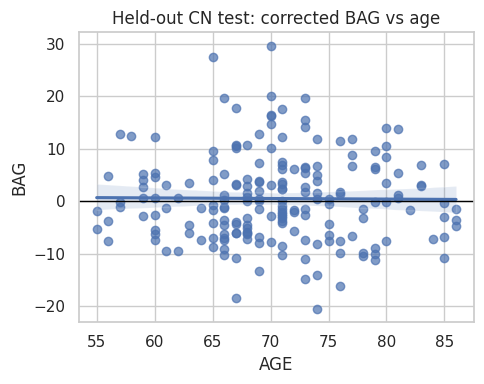

In [ ]:
val_pred = age_model.predict(cn_val[model_features])
bias_model = LinearRegression().fit(cn_val[['AGE']], val_pred)
alpha, beta = float(bias_model.intercept_), float(bias_model.coef_[0])
assert beta > 0, 'Unexpected non-positive calibration slope; inspect the selected model and validation split.'
print(f'Validation bias model: predicted age = {alpha:.3f} + {beta:.3f} × chronological age')

def apply_brain_age(frame):
    out = frame.copy()
    out['predicted_age_raw'] = age_model.predict(out[model_features])
    out['predicted_age_corrected'] = (out['predicted_age_raw'] - alpha) / beta
    out['BAG'] = out['predicted_age_corrected'] - out['AGE']
    return out

cn_test_scored = apply_brain_age(cn_test)
dummy_test = searches['Dummy mean age'].best_estimator_.predict(cn_test[model_features])
performance = pd.DataFrame([
    {'model': best_name, 'MAE': mean_absolute_error(cn_test_scored.AGE, cn_test_scored.predicted_age_corrected),
     'R2': r2_score(cn_test_scored.AGE, cn_test_scored.predicted_age_corrected),
     'BAG_age_correlation': cn_test_scored[['BAG', 'AGE']].corr().iloc[0, 1]},
    {'model': 'Dummy mean age', 'MAE': mean_absolute_error(cn_test.AGE, dummy_test),
     'R2': r2_score(cn_test.AGE, dummy_test), 'BAG_age_correlation': np.nan},
])
performance['MAE_improvement_vs_dummy_%'] = 100 * (1 - performance['MAE'] / performance.loc[performance.model.eq('Dummy mean age'), 'MAE'].iloc[0])
display(performance.round(3))
performance.to_csv(TABLE_DIR / 'model_performance.csv', index=False)

plt.figure(figsize=(5, 4))
sns.regplot(data=cn_test_scored, x='AGE', y='BAG', scatter_kws={'alpha': .7})
plt.axhline(0, color='black', lw=1); plt.title('Held-out CN test: corrected BAG vs age')
plt.tight_layout(); plt.savefig(FIG_DIR / 'cn_test_bag_vs_age.png', dpi=300); plt.show()

## 9. Primary analysis: diagnostic-stage association

The fitted CN reference model and frozen correction are now applied to the entire aligned baseline cohort. The adjusted model is:

`BAG ~ diagnosis + chronological age + sex + education`

Although BAG is age-corrected, including chronological age in the inferential model is conservative and protects against residual calibration effects. This analysis estimates *association*, not causality. Diagnosis is recorded as CN/MCI/Dementia because clinical dementia is not automatically biomarker-confirmed Alzheimer's disease.

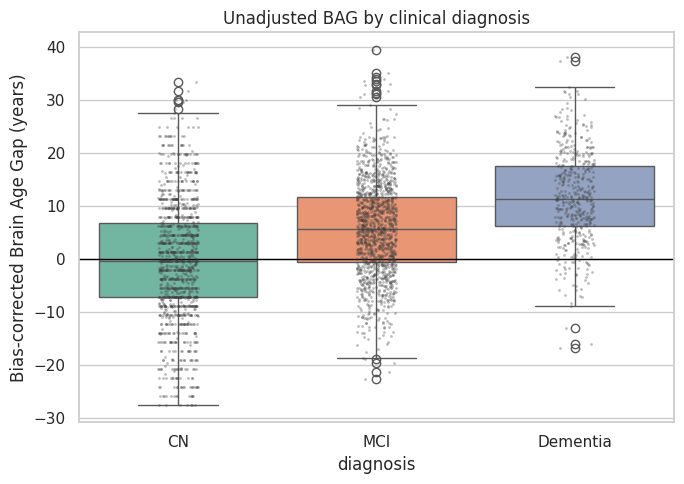

,sum_sq,df,F,PR(>F)
C(diagnosis),40281.882749,2.0,224.377238,8.941530e-92
C(PTGENDER),4352.124947,1.0,48.484217,4.042220e-12
AGE,14592.847313,1.0,162.569500,2.464132e-36
PTEDUCAT,0.357423,1.0,0.003982,9.496896e-01
Residual,280242.415125,3122.0,NaN,NaN


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BAG   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     164.7
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          9.15e-156
Time:                        03:29:31   Log-Likelihood:                -11469.
No. Observations:                3128   AIC:                         2.295e+04
Df Residuals:                    3122   BIC:                         2.299e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                  -19.4964      2.456     -7.940      0.000     -24.311     -14.682
C(diagnosis)[T.MCI]          5.2285      0.379     13.806      0.000       4.486       5.971
C(diagnosis)[T.Dementia]    10.5436      0.563     18.732      0.000       9.440      11.647
C(PTGENDER)[T.2.0]          -2.4545      0.355     -6.905      0.000      -3.151      -1.758
AGE                          0.2921      0.031      9.534      0.000       0.232       0.352
PTEDUCAT                    -0.0040      0.064     -0.062      0.950      -0.129       0.121
==============================================================================
Omnibus:                       17.792   Durbin-Watson:                   1.761
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.070
Skew:                           0.171   Prob(JB):                     0.000119
Kurtosis:                       3.146   Cond. No.                         876.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [ ]:
scored = apply_brain_age(cohort)
scored['diagnosis'] = pd.Categorical(scored['diagnosis'], categories=['CN', 'MCI', 'Dementia'])
scored['PTGENDER'] = scored['PTGENDER'].astype('category')

plot_df = scored.dropna(subset=['BAG', 'diagnosis'])
plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df, x='diagnosis', y='BAG', order=['CN', 'MCI', 'Dementia'], palette='Set2')
sns.stripplot(data=plot_df, x='diagnosis', y='BAG', order=['CN', 'MCI', 'Dementia'], color='0.25', alpha=.35, size=2)
plt.axhline(0, color='black', lw=1); plt.ylabel('Bias-corrected Brain Age Gap (years)')
plt.title('Unadjusted BAG by clinical diagnosis')
plt.tight_layout(); plt.savefig(FIG_DIR / 'bag_by_diagnosis.png', dpi=300); plt.show()

analysis_df = scored.dropna(subset=['BAG', 'AGE', 'PTGENDER', 'PTEDUCAT', 'diagnosis']).copy()
ancova_model = smf.ols('BAG ~ C(diagnosis) + AGE + C(PTGENDER) + PTEDUCAT', data=analysis_df).fit()
ancova_table = anova_lm(ancova_model, typ=2)
display(ancova_table)
display(ancova_model.get_robustcov_results(cov_type='HC3').summary())
ancova_table.to_csv(TABLE_DIR / 'ancova_diagnosis.csv')
scored.to_parquet(PROCESSED_DIR / 'baseline_scored_bag.parquet', index=False)

## 10. Secondary analysis: amyloid PET subset

Amyloid PET is not measured in every participant. This analysis therefore answers a narrower question in a selected PET-available subset; it cannot establish population-wide prevalence or eliminate selection bias. PET is matched to the baseline MRI by closest scan date within the same 180-day window.

The model includes clinical diagnosis to ask whether amyloid status explains BAG differences beyond the broad clinical stage. If few records are retained, report the sample size and treat results as exploratory.

Unmapped amyloid-status codes: []
PET-aligned analysis sample: 1798


,count
amyloid_status,
Negative,972
Positive,826


,sum_sq,df,F,PR(>F)
C(amyloid_status),1872.297102,1.0,23.354220,1.462409e-06
C(diagnosis),13449.458974,2.0,83.881351,1.504431e-35
C(PTGENDER),1825.539110,1.0,22.770981,1.973027e-06
AGE,8907.492165,1.0,111.108183,3.021474e-25
PTEDUCAT,39.775041,1.0,0.496137,4.812942e-01
Residual,143583.650429,1791.0,NaN,NaN


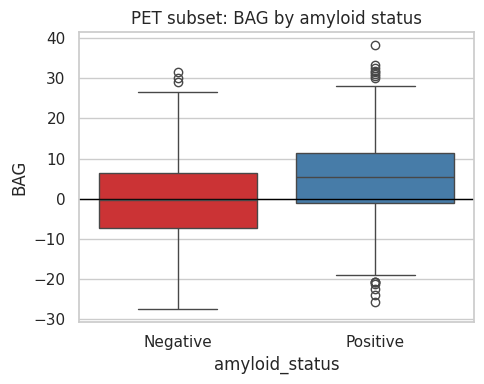

In [ ]:
if amyloid is None:
    print('Amyloid PET file not found: secondary analysis skipped.')

else:
    amyloid = to_date(amyloid, 'SCANDATE')
    amyloid_keep = [
        c for c in ['AMYLOID_STATUS', 'CENTILOIDS', 'SUMMARY_SUVR']
        if c in amyloid.columns
    ]
    amyloid_clean = amyloid.dropna(subset=['SCANDATE']).copy()

    amyloid_df = nearest_by_rid(
        scored,
        amyloid_clean,
        'SCANDATE',
        amyloid_keep,
        MAX_ALIGNMENT_DAYS
    )

    # ADNI UCBERKELEY_AMY_6MM의 AMYLOID_STATUS:
    # 0 = Amyloid Negative, 1 = Amyloid Positive
    amyloid_status_map = {
        0: 'Negative',
        1: 'Positive',
        '0': 'Negative',
        '1': 'Positive',
        'Negative': 'Negative',
        'Positive': 'Positive'
    }

    amyloid_df['amyloid_status'] = amyloid_df['AMYLOID_STATUS'].map(
        amyloid_status_map
    )

    unknown_status = amyloid_df.loc[
        amyloid_df['AMYLOID_STATUS'].notna()
        & amyloid_df['amyloid_status'].isna(),
        'AMYLOID_STATUS'
    ].unique()

    print('Unmapped amyloid-status codes:', unknown_status)

    amyloid_df = amyloid_df.dropna(
        subset=[
            'amyloid_status', 'BAG', 'AGE',
            'PTGENDER', 'PTEDUCAT', 'diagnosis'
        ]
    )

    print('PET-aligned analysis sample:', len(amyloid_df))
    display(amyloid_df['amyloid_status'].value_counts())

    if amyloid_df['amyloid_status'].nunique() == 2:
        amyloid_model = smf.ols(
            'BAG ~ C(amyloid_status) + C(diagnosis) + AGE + '
            'C(PTGENDER) + PTEDUCAT',
            data=amyloid_df
        ).fit()

        amyloid_table = anova_lm(amyloid_model, typ=2)
        display(amyloid_table)
        amyloid_table.to_csv(TABLE_DIR / 'ancova_amyloid.csv')

        plt.figure(figsize=(5, 4))
        sns.boxplot(
            data=amyloid_df,
            x='amyloid_status',
            y='BAG',
            palette='Set1'
        )
        plt.axhline(0, color='black', lw=1)
        plt.title('PET subset: BAG by amyloid status')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'bag_by_amyloid_status.png', dpi=300)
        plt.show()

    else:
        print('Amyloid categories are insufficient after date alignment; do not run this comparison.')

## 11. Interpretable age-prediction features

Permutation importance asks how much the held-out CN test MAE worsens when one input feature is randomly shuffled. It is more defensible than impurity-based tree importance but still reflects **predictive contribution to chronological age**, not a causal disease mechanism. Highly correlated ROI measurements can share or mask importance.

For biological interpretation, discuss important medial temporal, hippocampal, entorhinal, frontal, or global atrophy variables as components of normal structural ageing. Only then relate the group-level BAG result to Alzheimer-spectrum neurodegeneration, and explicitly avoid claiming that an ROI causes disease.

In [27]:
fs_dd = data_dict[data_dict['TBLNAME'].eq('UCSFFSX7')].copy()
fs_dd['TEXT'] = fs_dd['TEXT'].str.replace('Volume of ', '', regex=False).str.replace('Mean thickness of ', '', regex=False)
feature_labels = pd.Series(fs_dd['TEXT'].values, index=fs_dd['FLDNAME']).to_dict()


<>:15: SyntaxWarning: invalid escape sequence '\('
<>:15: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_3780/2593299360.py:15: SyntaxWarning: invalid escape sequence '\('
  plt.barh(top['anatomical_label'].str.replace('Subcortical Volume \(aseg.stats\) of ', '', regex=True), top['importance_mae_increase'])


,feature_code,importance_mae_increase,importance_sd,anatomical_label
25,ST127SV_ICV_ratio,0.204031,0.049715,ST127SV_ICV_ratio
44,ST30SV_ICV_ratio,0.177753,0.054139,ST30SV_ICV_ratio
26,ST128SV_ICV_ratio,0.167258,0.034266,ST128SV_ICV_ratio
20,ST11SV_ICV_ratio,0.097076,0.036948,ST11SV_ICV_ratio
97,ST89SV_ICV_ratio,0.082087,0.028392,ST89SV_ICV_ratio
76,ST61SV_ICV_ratio,0.039775,0.015813,ST61SV_ICV_ratio
50,ST37SV_ICV_ratio,0.021784,0.013937,ST37SV_ICV_ratio
28,ST12SV_ICV_ratio,0.018412,0.008344,ST12SV_ICV_ratio
91,ST80SV_ICV_ratio,0.016325,0.007007,ST80SV_ICV_ratio
126,ST111TA,0.014483,0.009826,Thickness Average (aparc.stats) of RightPrecuneus


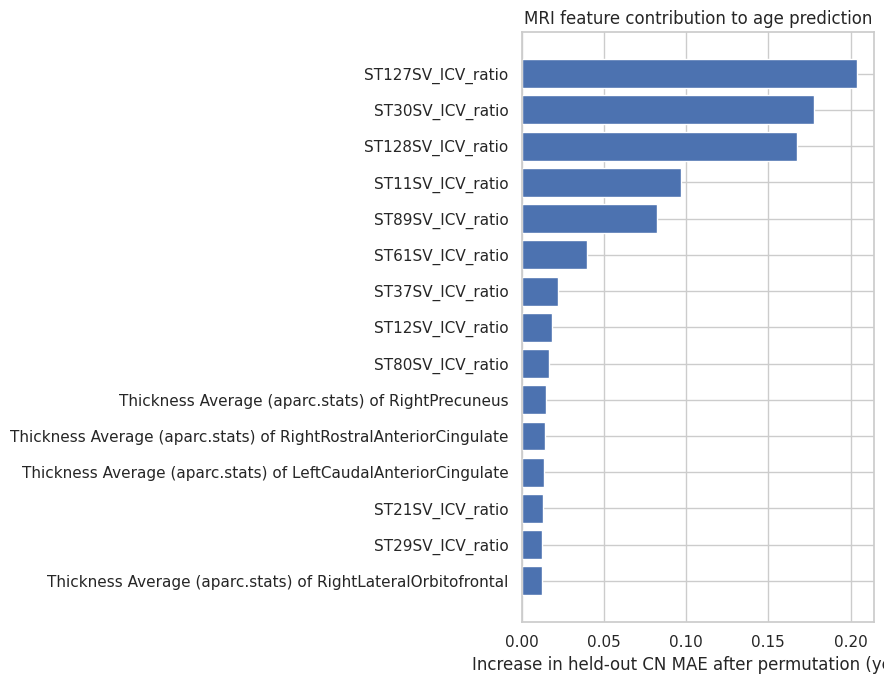

In [28]:
perm = permutation_importance(age_model, cn_test[model_features], cn_test['AGE'], scoring='neg_mean_absolute_error',
                              n_repeats=30, random_state=SEED, n_jobs=-1)
importance = pd.DataFrame({
    'feature_code': model_features,
    'importance_mae_increase': perm.importances_mean,
    'importance_sd': perm.importances_std,
})
importance['anatomical_label'] = importance['feature_code'].map(feature_labels).fillna(importance['feature_code'])
importance = importance.sort_values('importance_mae_increase', ascending=False)
display(importance.head(15))
importance.to_csv(TABLE_DIR / 'permutation_importance.csv', index=False)

top = importance.head(15).sort_values('importance_mae_increase')
plt.figure(figsize=(9, 7))
plt.barh(top['anatomical_label'].str.replace('Subcortical Volume \(aseg.stats\) of ', '', regex=True), top['importance_mae_increase'])
plt.xlabel('Increase in held-out CN MAE after permutation (years)')
plt.title('MRI feature contribution to age prediction')
plt.tight_layout(); plt.savefig(FIG_DIR / 'permutation_importance_top15.png', dpi=300); plt.show()

## 12. Reporting checklist and next steps

Before presenting results, report: (1) the final RID count in each diagnosis group and in each CN partition; (2) the MRI-to-diagnosis/PET alignment window and actual alignment-day distribution; (3) QC exclusions and missing-feature threshold; (4) model, hyperparameters, CV MAE, untouched-CN-test MAE/R², and test BAG–age correlation; (5) adjusted regression coefficients with confidence intervals and multiplicity policy; and (6) the limited generalisability of ADNI.

### Biological interpretation template
If corrected BAG is higher in MCI or dementia, conclude: *their baseline FreeSurfer ROI pattern was more similar to that of an older CN reference brain after adjustment for age, sex, and education.* This is compatible with neurodegeneration but does not prove that BAG is a disease-specific biomarker. If amyloid positivity is associated with BAG in the PET subset, conclude that this is an association in the selected ADNI PET sample.

### Legitimate extension
A longitudinal study can estimate within-person BAG change per year using repeated MRI visits and a mixed-effects model. Only that extension addresses rate of change; a single baseline BAG must not be described as a rate or acceleration.